In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۶ — تکنیک‌های یادگیری تجمعی (Ensemble Learning)
## درس ۱۰: کالیبراسیون با Ensembleها (Platt Scaling، نمای کلی Isotonic Regression)

**نویسنده:** Abolfazl Mohammadijoo  
**مخزن:** آموزش‌های یادگیری ماشین (۳۷ فصل)

### چرا این درس مهم است؟
Ensembleها (Random Forest، Gradient Boosting، ExtraTrees، Voting/Stacking) معمولاً کیفیت **رتبه‌بندی** (مثل AUC) و **دقت** را بهتر می‌کنند، اما احتمال‌های پیش‌بینی‌شده‌ی آن‌ها ممکن است **بدکالیبره** باشند—یعنی بیش از حد مطمئن یا کمتر از حد لازم مطمئن. در بسیاری از سامانه‌های واقعی (ریسک، پزشکی، تقلب، مالی، آستانه‌گذاری در توصیه‌گرها) شما به *احتمال‌های کالیبره* نیاز دارید، نه فقط برچسب درست.

در این درس یاد می‌گیرید:
- تعریف **کالیبراسیون احتمال** و تفاوت آن با discrimination (مثل AUC/accuracy).
- **Proper scoring rule**ها (log loss و Brier score) و اینکه چرا به احتمال‌های کالیبره «پاداش» می‌دهند.
- استخراج و استفاده از **Platt Scaling** (کالیبراسیون سیگموید) و اینکه چه زمانی خوب کار می‌کند.
- درک **Isotonic Regression** به عنوان نگاشت کالیبراسیون یکنواختِ ناپارامتری.
- کالیبره‌کردن درست **مدل‌های Ensemble** با داده‌ی جداگانه یا cross-validation (بدون leakage).
- اندازه‌گیری کالیبراسیون با **reliability diagram**، **ECE**، **Brier score** و **log loss**.

> **نکته مهم:** همه‌ی ریاضی در سلول‌های markdown با $...$ و $$...$$ نوشته شده است (نه \(\) یا \[\]).  
> **مسیر دیتاست‌ها:** از مسیر نسبی مثل `"../../../Datasets/Classification/diabetes.csv"` استفاده کنید.


### نقشه‌ی مسیر (چه چیزی می‌سازیم؟)
همان workflow کالیبراسیون را روی **چند دیتاست** (دودویی + چندکلاسه) و **چند Ensemble** اجرا می‌کنیم:

1. آموزش یک مدل Ensemble (مثل RandomForest یا GradientBoosting).
2. ارزیابی discrimination در برابر calibration:
   - Discrimination: Accuracy، ROC AUC
   - Calibration: منحنی اطمینان (reliability curve)، ECE، Brier score، Log loss
3. اعمال کالیبراسیون:
   - **Platt scaling**: برازش $p(y=1\mid s)=\sigma(As+B)$
   - **Isotonic regression**: برازش یک تابع یکنواخت $f(s)$
4. ارزیابی مجدد روی یک *test set واقعی*.

همچنین بهترین روش‌ها را می‌بینیم:
- **هرگز** روی همان داده‌ای که مدل پایه را آموزش داده‌اید کالیبره نکنید (مگر اینکه CV را درست استفاده کنید).
- از **CalibratedClassifierCV** یا یک جداسازی دقیق train/val/test استفاده کنید.
- انتخاب sigmoid یا isotonic را بر اساس اندازه‌ی داده، نوع مدل، و ریسک overfitting انجام دهید.


In [2]:
# Core scientific Python
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Utilities
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple, Callable, List, Optional

# Scikit-learn: models, calibration, metrics, preprocessing, splitting
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

from sklearn.calibration import CalibratedClassifierCV, calibration_curve, CalibrationDisplay
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier

# Reproducibility
RNG = np.random.default_rng(42)

# ------------------------------------------------------------------------------------
# NOTE ABOUT THIS NOTEBOOK
# ------------------------------------------------------------------------------------
# This notebook focuses on *probability calibration*.
# - We are not trying to maximize accuracy at all costs.
# - We want predicted probabilities to match empirical frequencies.
#
# To avoid "calibration leakage", we will either:
# (A) use a Train / Calibration / Test split, OR
# (B) use cross-validated calibration (CalibratedClassifierCV).
#
# The dataset files are expected to exist in your repository with paths like:
#   ../../../Datasets/Classification/diabetes.csv
#
# If you run this notebook elsewhere, adjust the paths accordingly.
# ------------------------------------------------------------------------------------


In [3]:
# ------------------------------------------------------------------------------------
# Dataset loaders (CSV files in your repo)
# ------------------------------------------------------------------------------------
DATASETS = {
    "diabetes": Path("../../../Datasets/Classification/diabetes.csv"),
    "iris": Path("../../../Datasets/Classification/iris.csv"),
    "wine_quality": Path("../../../Datasets/Classification/Wine_Quality.csv"),
    "drug200": Path("../../../Datasets/Classification/drug200.csv"),
    "glass": Path("../../../Datasets/Classification/glass.csv"),
    # You can add more classification datasets here if desired.
}

def load_diabetes() -> Tuple[pd.DataFrame, np.ndarray]:
    df = pd.read_csv(DATASETS["diabetes"])
    y = (df["classification"].astype(str).str.lower() == "diabetic").astype(int).to_numpy()
    X = df.drop(columns=["classification"])
    return X, y

def load_iris() -> Tuple[pd.DataFrame, np.ndarray]:
    df = pd.read_csv(DATASETS["iris"])
    y = df["classification"].astype(str).to_numpy()
    X = df.drop(columns=["classification"])
    return X, y

def load_wine_quality_binary(threshold: int = 7) -> Tuple[pd.DataFrame, np.ndarray]:
    # Convert the numeric quality score into a binary label:
    # good (>= threshold) vs not-good (< threshold).
    df = pd.read_csv(DATASETS["wine_quality"])
    y = (df["quality"].astype(int) >= threshold).astype(int).to_numpy()
    X = df.drop(columns=["quality"])
    return X, y

def load_drug200() -> Tuple[pd.DataFrame, np.ndarray]:
    df = pd.read_csv(DATASETS["drug200"])
    y = df["Drug"].astype(str).to_numpy()
    X = df.drop(columns=["Drug"])
    return X, y

def load_glass() -> Tuple[pd.DataFrame, np.ndarray]:
    df = pd.read_csv(DATASETS["glass"])
    y = df["Type"].astype(str).to_numpy()
    X = df.drop(columns=["Type"])
    return X, y

LOADERS: Dict[str, Callable[[], Tuple[pd.DataFrame, np.ndarray]]] = {
    "diabetes": load_diabetes,
    "iris": load_iris,
    "wine_quality_binary": load_wine_quality_binary,
    "drug200": load_drug200,
    "glass": load_glass,
}

def summarize_dataset(X: pd.DataFrame, y: np.ndarray, name: str, max_rows: int = 5) -> None:
    print(f"Dataset: {name}")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    # Show top rows (as requested in your repo style)
    display(pd.concat([X.head(max_rows), pd.Series(y[:max_rows], name='target')], axis=1))

# Quick sanity check: load and display a few datasets
for name in ["diabetes", "wine_quality_binary", "iris"]:
    X, y = LOADERS[name]()
    summarize_dataset(X, y, name=name)


Dataset: diabetes
X shape: (768, 8)
y shape: (768,)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,target
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Dataset: wine_quality_binary
X shape: (4898, 11)
y shape: (4898,)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,0
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,0
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,0
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,0
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,0


Dataset: iris
X shape: (150, 4)
y shape: (150,)


,sepal_length,sepal_width,petal_length,petal_width,target
0,5.4,3.7,1.5,0.2,Iris-setosa
1,4.8,3.4,1.6,0.2,Iris-setosa
2,4.8,3.0,1.4,0.1,Iris-setosa
3,4.3,3.0,1.1,0.1,Iris-setosa
4,5.8,4.0,1.2,0.2,Iris-setosa


In [4]:
# --- Safety setup: allow running this cell after Restart Kernel / running cells out of order ---
if "__CH6_L10_SETUP__" not in globals():
    # If you run a single experiment cell directly, we re-define the minimal setup here.
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path
    from typing import Tuple

    from sklearn.model_selection import train_test_split, StratifiedKFold
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
    from sklearn.calibration import calibration_curve, CalibratedClassifierCV
    from sklearn.isotonic import IsotonicRegression
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier

    DATASETS = {
        "diabetes": Path("../../../Datasets/Classification/diabetes.csv"),
        "iris": Path("../../../Datasets/Classification/iris.csv"),
        "wine_quality": Path("../../../Datasets/Classification/Wine_Quality.csv"),
    }

    def load_diabetes() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["diabetes"])
        y = (df["classification"].astype(str).str.lower() == "diabetic").astype(int).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_iris() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["iris"])
        y = df["classification"].astype(str).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_wine_quality_binary(threshold: int = 7) -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["wine_quality"])
        y = (df["quality"] >= threshold).astype(int).to_numpy()
        X = df.drop(columns=["quality"])
        return X, y

    def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
        num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
        cat_cols = [c for c in X.columns if c not in num_cols]
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
        cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
        return ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])

    def expected_calibration_error(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10) -> float:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        bins = np.linspace(0.0, 1.0, n_bins + 1)
        ece = 0.0
        for i in range(n_bins):
            lo, hi = bins[i], bins[i + 1]
            mask = (p_pred >= lo) & (p_pred < hi) if i < n_bins - 1 else (p_pred >= lo) & (p_pred <= hi)
            if not np.any(mask):
                continue
            acc = y_true[mask].mean()
            conf = p_pred[mask].mean()
            ece += mask.mean() * abs(acc - conf)
        return float(ece)

    def evaluate_binary(y_true: np.ndarray, p_pred: np.ndarray) -> dict:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        eps = 1e-15
        p_clip = np.clip(p_pred, eps, 1 - eps)
        y_hat = (p_pred >= 0.5).astype(int)
        return {
            "brier": float(brier_score_loss(y_true, p_clip)),
            "log_loss": float(log_loss(y_true, np.c_[1 - p_clip, p_clip])),
            "roc_auc": float(roc_auc_score(y_true, p_clip)),
            "accuracy@0.5": float(accuracy_score(y_true, y_hat)),
            "ece": float(expected_calibration_error(y_true, p_clip, n_bins=10)),
        }

    def plot_reliability(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10, title: str = "Reliability diagram"):
        frac_pos, mean_pred = calibration_curve(np.asarray(y_true), np.asarray(p_pred), n_bins=n_bins, strategy="uniform")
        plt.figure(figsize=(6, 6))
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.plot(mean_pred, frac_pos, marker="o")
        plt.xlabel("Mean predicted probability")
        plt.ylabel("Fraction of positives")
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.show()

    def print_metrics_table(results: dict, sort_by: str = "brier", ascending: bool = True):
        rows = []
        for name, metrics in results.items():
            row = {"model": name}
            if isinstance(metrics, dict):
                row.update(metrics)
            rows.append(row)
        df = pd.DataFrame(rows)
        if sort_by in df.columns:
            df = df.sort_values(by=sort_by, ascending=ascending)
        try:
            from IPython.display import display
            display(df)
        except Exception:
            print(df.to_string(index=False))

    __CH6_L10_SETUP__ = True

# ------------------------------------------------------------------------------------
# Helper utilities (preprocessing + calibration plots + proper scoring rules)
# ------------------------------------------------------------------------------------
# NOTE: Code/comments stay in English (required for *_Fa.ipynb as well)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
from sklearn.calibration import calibration_curve

def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """Numeric: median impute + standardize. Categorical: most_frequent + one-hot."""
    num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    cat_cols = [c for c in X.columns if c not in num_cols]

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ])

def expected_calibration_error(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10) -> float:
    """ECE via equal-width bins in [0,1]."""
    y_true = np.asarray(y_true)
    p_pred = np.asarray(p_pred)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (p_pred >= lo) & (p_pred < hi) if i < n_bins - 1 else (p_pred >= lo) & (p_pred <= hi)
        if not np.any(mask):
            continue
        acc = y_true[mask].mean()
        conf = p_pred[mask].mean()
        ece += mask.mean() * abs(acc - conf)
    return float(ece)

def evaluate_binary(y_true: np.ndarray, p_pred: np.ndarray) -> dict:
    """Return a compact set of metrics for a binary probabilistic classifier."""
    y_true = np.asarray(y_true)
    p_pred = np.asarray(p_pred)
    eps = 1e-15
    p_clip = np.clip(p_pred, eps, 1 - eps)
    y_hat = (p_pred >= 0.5).astype(int)
    return {
        "brier": float(brier_score_loss(y_true, p_clip)),
        "log_loss": float(log_loss(y_true, np.c_[1 - p_clip, p_clip])),
        "roc_auc": float(roc_auc_score(y_true, p_clip)),
        "accuracy@0.5": float(accuracy_score(y_true, y_hat)),
        "ece": float(expected_calibration_error(y_true, p_clip, n_bins=10)),
    }

def plot_reliability(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10, title: str = "Reliability diagram"):
    """Plot a reliability diagram using sklearn.calibration_curve."""
    y_true = np.asarray(y_true)
    p_pred = np.asarray(p_pred)
    frac_pos, mean_pred = calibration_curve(y_true, p_pred, n_bins=n_bins, strategy="uniform")
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

def print_metrics_table(results: dict, sort_by: str = "brier", ascending: bool = True):
    """Pretty-print a dict of metrics returned by evaluate_binary."""
    if not isinstance(results, dict) or len(results) == 0:
        print("No results to display.")
        return
    rows = []
    for name, metrics in results.items():
        row = {"model": name}
        if isinstance(metrics, dict):
            row.update(metrics)
        rows.append(row)
    df = pd.DataFrame(rows)
    if sort_by in df.columns:
        df = df.sort_values(by=sort_by, ascending=ascending)
    try:
        from IPython.display import display
        display(df)
    except Exception:
        print(df.to_string(index=False))

__CH6_L10_SETUP__ = True


## ۱) «احتمال کالیبره» دقیقاً یعنی چه؟

یک دسته‌بند را در نظر بگیرید که یک امتیاز $s(x)\\in[0,1]$ (معمولاً $\\hat{p}(y=1\\mid x)$) خروجی می‌دهد.  
این مدل **کاملاً کالیبره** است اگر:

$$
\\mathbb{P}(Y=1\\mid s(X)=p)=p \\quad \\text{برای همه‌ی } p\\in[0,1].
$$

تعبیر: بین همه‌ی نمونه‌هایی که مدل می‌گوید «۰٫۷۰»، حدود ۷۰٪ واقعاً مثبت باشند.

### Calibration در برابر discrimination
یک مدل ممکن است:
- **discrimination** خوبی داشته باشد (مثلاً رتبه‌بندی درست؛ AUC بالا)،
- اما **calibration** ضعیفی داشته باشد (مقیاس احتمال‌ها درست نباشد).

discrimination درباره‌ی *ترتیب* است؛ calibration درباره‌ی *معنای عددی* احتمال‌ها.

### چرا Ensembleها ممکن است بدکالیبره باشند؟
الگوهای رایج:
- **Boosting** می‌تواند **بیش‌اطمینان** شود (marginهای بزرگ).
- **Random Forest** اغلب **کم‌اطمینان** است (احتمال‌ها به سمت ۰٫۵ جمع می‌شوند)، اما این به depth، leaf size و عدم‌توازن کلاس‌ها وابسته است.
- **Stacking/Voting** خروجی مدل‌های متفاوت را ترکیب می‌کند؛ این ترکیب می‌تواند احتمال‌ها را به‌هم بزند مگر اینکه کالیبره شود.

بنابراین یک **لایه‌ی کالیبراسیون** اضافه می‌کنیم: یک نگاشت پس‌پردازشی $f$ به‌طوری‌که:
$$
\\hat{p}_{\\text{cal}}(x) = f\\big( s(x) \\big)
$$
که در آن $s(x)$ می‌تواند احتمال خام، margin، یا امتیازی شبیه logit باشد.


## ۲) Proper scoring ruleها: چرا log loss و Brier score به calibration اهمیت می‌دهند؟

یک **scoring rule** به یک پیش‌بینی احتمالاتی $p$ وقتی برچسب واقعی $y\\in\\{0,1\\}$ است، یک loss اختصاص می‌دهد.

### Log loss (cross-entropy)
$$
\\ell_{\\text{log}}(p,y) = -\\big(y\\log p + (1-y)\\log(1-p)\\big).
$$

### Brier score (خطای مربعی روی احتمال‌ها)
$$
\\ell_{\\text{Brier}}(p,y) = (p-y)^2.
$$

یک scoring rule **proper** است اگر امید ریاضی loss با پیش‌بینی **احتمال شرطی واقعی** کمینه شود:
$$
p^*(x)=\\mathbb{P}(Y=1\\mid X=x).
$$

**نتیجه‌ی مهم:** اگر log loss یا Brier score برایتان مهم است، بهترکردن calibration (نزدیک‌کردن $p$ به $p^*$) هدف را بهتر می‌کند *حتی اگر accuracy تغییر نکند*.

### یک تجزیه‌ی مفید (شهود)
برای Brier score یک تجزیه‌ی کلاسیک (Murphy) این اجزاء را جدا می‌کند:
- **Reliability** (خطای calibration)،
- **Resolution** (اینکه پیش‌بینی‌ها چقدر بین نمونه‌ها متفاوت‌اند)،
- **Uncertainty** (شیوع کلاس).

اینجا اثبات کامل را نمی‌آوریم، ولی از شهود استفاده می‌کنیم:  
> می‌توانید Brier score را با کالیبره‌تر کردن احتمال‌ها (reliability بهتر) و همچنین «اطلاعاتی‌تر» کردن آن‌ها (resolution بهتر) کاهش دهید.


## ۶) سنجش کالیبراسیون: reliability diagram، ECE، Brier، log loss

### Reliability diagram (calibration curve)
1. پیش‌بینی‌ها را به $K$ بازه (bin) تقسیم کنید (مثلاً ۱۰ bin).
2. برای هر binِ $k$ محاسبه کنید:
   - میانگین احتمال پیش‌بینی‌شده: $\\bar{p}_k$
   - دقت تجربی (سهم مثبت‌ها): $\\bar{y}_k$
3. نمودار $\\bar{y}_k$ در برابر $\\bar{p}_k$ را رسم کنید. کالیبراسیون کامل همان خط قطری است.

### Expected Calibration Error (ECE)
یک تعریف رایج:

$$
\\text{ECE} = \\sum_{k=1}^K \\frac{n_k}{n}\\,\\big|\\bar{y}_k - \\bar{p}_k\\big|.
$$

ECE تفسیرپذیر است، اما به انتخاب binها وابسته است.

### Brier score و log loss
- Brier score: میانگین $(p-y)^2$ (کمتر بهتر است).
- Log loss: پیش‌بینی‌های غلطِ بسیار مطمئن را شدیداً جریمه می‌کند (کمتر بهتر است).

همه‌ی این معیارها را محاسبه می‌کنیم و «قبل و بعد» کالیبراسیون را مقایسه می‌کنیم.


## ۶٫۵) چرا calibration برای تصمیم‌گیری مهم است؟ (آستانه‌گذاری، هزینه‌ها، و utility)

فرض کنید باید یک عمل $a\\in\\{0,1\\}$ انتخاب کنید (مثلاً «تأیید وام» یا «رد»)، بر اساس احتمال پیش‌بینی‌شده $p=\\hat{p}(y=1\\mid x)$.
هزینه‌ی false positive را $C_{FP}$ و هزینه‌ی false negative را $C_{FN}$ در نظر بگیرید.

اگر وقتی $p\\ge t$ پیش‌بینی مثبت کنید، آستانه‌ی بهینه‌ی بیزی (با این هزینه‌ها) برابر است با:

$$
t^* = \\frac{C_{FP}}{C_{FP}+C_{FN}}.
$$

این فرمول فرض می‌کند $p$ **کالیبره** است (یعنی تخمین خوبی از $\\mathbb{P}(Y=1\\mid x)$ است).
اگر مدل بدکالیبره باشد، آستانه‌ی $t^*$ دیگر معنای مورد نظر را ندارد و مبادله‌ی هزینه‌ها اشتباه می‌شود.

**نکته‌ی عملی:** calibration وقتی حیاتی است که:
- برای داده‌ی نامتوازن آستانه تنظیم می‌کنید،
- هزینه/ارزش مورد انتظار را محاسبه می‌کنید،
- احتمال‌ها را به سیستم‌های پایین‌دستی می‌دهید (ranker، شبیه‌ساز، موتور ریسک)،
- نیاز دارید احتمال‌ها برای انسان قابل تفسیر باشند.


## ۵) تله‌ی leakage: چگونه کالیبره کنیم بدون اینکه خودمان را فریب بدهیم؟

اگر مدل پایه را روی داده‌ی آموزش fit کنید و سپس کالیبراتور را روی **همان** داده fit کنید، تقریباً همیشه
به معیارهای کالیبراسیونِ بیش از حد خوش‌بینانه می‌رسید—چون امتیازهای مدل پایه، جزئیات آن داده را «حفظ» کرده‌اند.

### پروتکل‌های درست

**پروتکل A — Train/Calibrate/Test**
1. داده را به Train / Calib / Test تقسیم کنید.
2. مدل پایه را روی Train آموزش دهید.
3. کالیبراتور (sigmoid یا isotonic) را روی Calib با استفاده از امتیازهای مدل پایه fit کنید.
4. روی Test ارزیابی کنید.

**پروتکل B — کالیبراسیون با cross-validation (پیشنهادی)**
از cross-validation استفاده کنید تا برای هر نمونه‌ی training، امتیاز out-of-fold تولید شود و کالیبراسیون روی همان امتیازها fit شود.
در scikit-learn این دقیقاً کاری است که `CalibratedClassifierCV` انجام می‌دهد.

### چه چیزی کالیبره می‌شود؟
کالیبراسیون روی یک *امتیاز* انجام می‌شود:
- برای مدل‌هایی که `predict_proba` دارند، می‌توانید احتمال خام را کالیبره کنید.
- برای مدل‌هایی که `decision_function` دارند، می‌توانید margin را کالیبره کنید.

برای Platt scaling، استفاده از margin رایج است چون می‌تواند اعتماد مدل را بهتر از احتمال بریده‌شده نمایش دهد.


## ۳) Platt Scaling (کالیبراسیون سیگموید)

### ایده
بسیاری از دسته‌بندها یک **margin** یا امتیاز $s(x)$ خروجی می‌دهند که هرچه بزرگ‌تر باشد یعنی «مثبت‌تر».  
Platt scaling روی این امتیاز یک logistic regression برازش می‌کند:

$$
\\hat{p}(y=1\\mid s)=\\sigma(As+B)=\\frac{1}{1+\\exp(As+B)}.
$$

در اینجا $A$ و $B$ روی یک **calibration set** (نه داده‌ی آموزش) یادگرفته می‌شوند.

### ارتباط با بیشینه‌سازی درست‌نمایی (Maximum Likelihood)
با داشتن داده‌های کالیبراسیون $(s_i,y_i)$ که $y_i\\in\\{0,1\\}$، Platt scaling پارامترهای $(A,B)$ را طوری انتخاب می‌کند که کمینه شود:

$$
\\mathcal{L}(A,B)= -\\sum_{i=1}^n \\big(y_i\\log \\sigma(As_i+B) + (1-y_i)\\log(1-\\sigma(As_i+B))\\big).
$$

این دقیقاً همان logistic regression با یک ویژگی $s$ (به‌علاوه‌ی عرض از مبدأ) است.

### چه زمانی sigmoid calibration مناسب است؟
Sigmoid calibration **پارامتری** است (۲ پارامتر). معمولاً خوب کار می‌کند وقتی:
- بدکالیبراسیونی شکل «S» دارد (بیش‌اطمینانی/کم‌اطمینانی سیستماتیک)،
- calibration set خیلی بزرگ نیست،
- می‌خواهید نسبت به overfitting مقاوم‌تر باشید.

اگر تابع کالیبراسیون واقعی شکل پیچیده‌ای داشته باشد، ممکن است خیلی سخت‌گیرانه/محدود باشد.


## ۴) Isotonic Regression (کالیبراسیون یکنواختِ ناپارامتری)

### ایده
به جای تحمیل یک منحنی S-شکل، **هر** تابع غیرکاهشی $f$ را یاد می‌گیریم:

$$
\\hat{p}(y=1\\mid s)=f(s), \\qquad f\\ \\text{غیرکاهشی است}.
$$

یک فرمول‌بندی رایج (با خطای مربعی) این است:

$$
\\min_{f\\ \\text{غیرکاهشی}} \\sum_{i=1}^n \\big(y_i - f(s_i)\\big)^2.
$$

راه‌حل یک تابع یکنواخت **پله‌ای (piecewise-constant)** است که به‌صورت کارا با الگوریتم
**Pool-Adjacent-Violators (PAV)** به دست می‌آید.

### چرا قید یکنواختی؟
بیشتر دسته‌بندها امتیازی می‌دهند که هرچه بزرگ‌تر باشد یعنی «مثبت‌تر».  
کالیبراسیون باید این ترتیب را حفظ کند (نباید امتیاز بزرگ‌تر را به احتمال کوچک‌تر تبدیل کند).

### چه زمانی isotonic مناسب است؟
Isotonic regression **انعطاف‌پذیر** است اما وقتی داده‌ی کالیبراسیون کوچک باشد می‌تواند **overfit** کند.  
از آن استفاده کنید وقتی:
- calibration set به اندازه‌ی کافی بزرگ است،
- فکر می‌کنید منحنی کالیبراسیون با sigmoid خوب تقریب نمی‌شود،
- می‌توانید کمی واریانس بیشتر را بپذیرید.

یک قاعده‌ی عملی: isotonic معمولاً برای پایداری به **هزاران** نمونه‌ی کالیبراسیون نیاز دارد.


## آزمایش‌های عملی

چند آزمایش اجرا می‌کنیم:

- **Experiment 1:** Diabetes (دودویی) با پروتکل دقیق Train/Calib/Test (کالیبراسیون hold-out).
- **Experiment 2:** Diabetes (دودویی) با کالیبراسیون cross-validated (`CalibratedClassifierCV`).
- **Experiment 3:** Iris (چندکلاسه) با کالیبراسیون cross-validated.
- **Experiment 4:** Wine quality (دودویی) برای نشان‌دادن overfitting در isotonic وقتی داده‌ی کالیبراسیون کوچک است.
- **Experiment 5:** یک benchmark کوچک روی چند دیتاست و چند Ensemble.

هنگام اجرای هر آزمایش، دو سؤال را در ذهن داشته باشید:
1. آیا discrimination تغییر کرد (accuracy/AUC)؟
2. آیا «معنای احتمال» بهتر شد (log loss / Brier / نمودار reliability)؟


In [5]:
# --- Safety setup: allow running this cell after Restart Kernel / running cells out of order ---
if "__CH6_L10_SETUP__" not in globals():
    # If you run a single experiment cell directly, we re-define the minimal setup here.
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path
    from typing import Tuple

    from sklearn.model_selection import train_test_split, StratifiedKFold
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
    from sklearn.calibration import calibration_curve, CalibratedClassifierCV
    from sklearn.isotonic import IsotonicRegression
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier

    DATASETS = {
        "diabetes": Path("../../../Datasets/Classification/diabetes.csv"),
        "iris": Path("../../../Datasets/Classification/iris.csv"),
        "wine_quality": Path("../../../Datasets/Classification/Wine_Quality.csv"),
    }

    def load_diabetes() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["diabetes"])
        y = (df["classification"].astype(str).str.lower() == "diabetic").astype(int).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_iris() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["iris"])
        y = df["classification"].astype(str).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_wine_quality_binary(threshold: int = 7) -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["wine_quality"])
        y = (df["quality"] >= threshold).astype(int).to_numpy()
        X = df.drop(columns=["quality"])
        return X, y

    def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
        num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
        cat_cols = [c for c in X.columns if c not in num_cols]
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
        cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
        return ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])

    def expected_calibration_error(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10) -> float:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        bins = np.linspace(0.0, 1.0, n_bins + 1)
        ece = 0.0
        for i in range(n_bins):
            lo, hi = bins[i], bins[i + 1]
            mask = (p_pred >= lo) & (p_pred < hi) if i < n_bins - 1 else (p_pred >= lo) & (p_pred <= hi)
            if not np.any(mask):
                continue
            acc = y_true[mask].mean()
            conf = p_pred[mask].mean()
            ece += mask.mean() * abs(acc - conf)
        return float(ece)

    def evaluate_binary(y_true: np.ndarray, p_pred: np.ndarray) -> dict:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        eps = 1e-15
        p_clip = np.clip(p_pred, eps, 1 - eps)
        y_hat = (p_pred >= 0.5).astype(int)
        return {
            "brier": float(brier_score_loss(y_true, p_clip)),
            "log_loss": float(log_loss(y_true, np.c_[1 - p_clip, p_clip])),
            "roc_auc": float(roc_auc_score(y_true, p_clip)),
            "accuracy@0.5": float(accuracy_score(y_true, y_hat)),
            "ece": float(expected_calibration_error(y_true, p_clip, n_bins=10)),
        }

    def plot_reliability(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10, title: str = "Reliability diagram"):
        frac_pos, mean_pred = calibration_curve(np.asarray(y_true), np.asarray(p_pred), n_bins=n_bins, strategy="uniform")
        plt.figure(figsize=(6, 6))
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.plot(mean_pred, frac_pos, marker="o")
        plt.xlabel("Mean predicted probability")
        plt.ylabel("Fraction of positives")
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.show()

    def print_metrics_table(results: dict, sort_by: str = "brier", ascending: bool = True):
        rows = []
        for name, metrics in results.items():
            row = {"model": name}
            if isinstance(metrics, dict):
                row.update(metrics)
            rows.append(row)
        df = pd.DataFrame(rows)
        if sort_by in df.columns:
            df = df.sort_values(by=sort_by, ascending=ascending)
        try:
            from IPython.display import display
            display(df)
        except Exception:
            print(df.to_string(index=False))

    __CH6_L10_SETUP__ = True

# ------------------------------------------------------------------------------------
# Experiment 1: Binary calibration on diabetes.csv
# ------------------------------------------------------------------------------------
X, y = load_diabetes()
pre = make_preprocessor(X)

# Split into Train / Calib / Test (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_calib, X_test, y_calib, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Two ensemble models to compare
base_models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

def fit_base_pipeline(model):
    # Pipeline = preprocessing + model
    return Pipeline(steps=[("pre", pre), ("model", model)])

results = {}

for model_name, model in base_models.items():
    pipe = fit_base_pipeline(model)
    pipe.fit(X_train, y_train)

    # Base probabilities (uncalibrated)
    p_base = pipe.predict_proba(X_test)[:, 1]
    results[f"{model_name} (base)"] = evaluate_binary(y_test, p_base)

    # -------------------------------------------------------------------------
    # Protocol A: Fit calibrator on the calibration split, then evaluate on test
    # -------------------------------------------------------------------------
    # We need calibration scores on X_calib and X_test.
    p_calib_scores = pipe.predict_proba(X_calib)[:, 1]

    # 1) Platt scaling (sigmoid)
    # We fit logistic regression on the *logit-like* input. Here we use the raw probability,
    # but a margin (decision_function) can work even better when available.
    # To reduce numerical issues, clip probabilities away from 0 and 1, then take logit.
    eps = 1e-6
    z_calib = np.log(np.clip(p_calib_scores, eps, 1 - eps) / np.clip(1 - p_calib_scores, eps, 1 - eps)).reshape(-1, 1)
    platt = LogisticRegression(solver="lbfgs")
    platt.fit(z_calib, y_calib)

    p_test_scores = pipe.predict_proba(X_test)[:, 1]
    z_test = np.log(np.clip(p_test_scores, eps, 1 - eps) / np.clip(1 - p_test_scores, eps, 1 - eps)).reshape(-1, 1)
    p_platt = platt.predict_proba(z_test)[:, 1]
    results[f"{model_name} + Platt (holdout)"] = evaluate_binary(y_test, p_platt)

    # 2) Isotonic regression (non-parametric monotone map)
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(p_calib_scores, y_calib)
    p_iso = iso.transform(p_test_scores)
    results[f"{model_name} + Isotonic (holdout)"] = evaluate_binary(y_test, p_iso)

# Show metrics
print_metrics_table(results)


,model,brier,log_loss,roc_auc,accuracy@0.5,ece
0,RandomForest (base),0.179560,0.529822,0.779936,0.720779,0.061343
1,RandomForest + Platt (holdout),0.179725,0.530235,0.779936,0.720779,0.061971
4,GradientBoosting + Platt (holdout),0.181154,0.537207,0.773772,0.720779,0.078007
5,GradientBoosting + Isotonic (holdout),0.181934,1.143265,0.770876,0.727273,0.089756
3,GradientBoosting (base),0.189491,0.569643,0.773772,0.694805,0.114021
2,RandomForest + Isotonic (holdout),0.189766,1.158506,0.753970,0.714286,0.071887


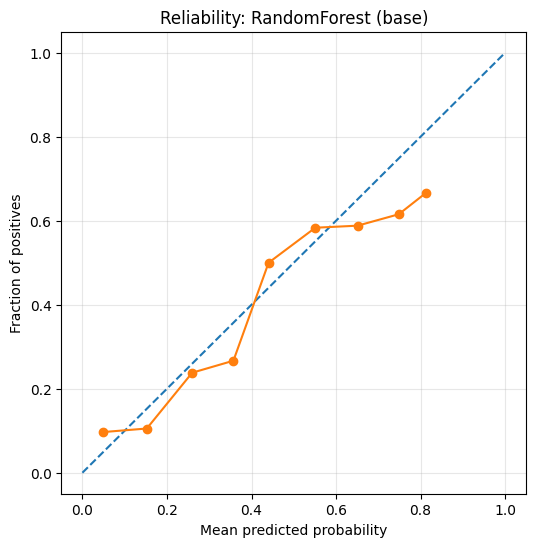

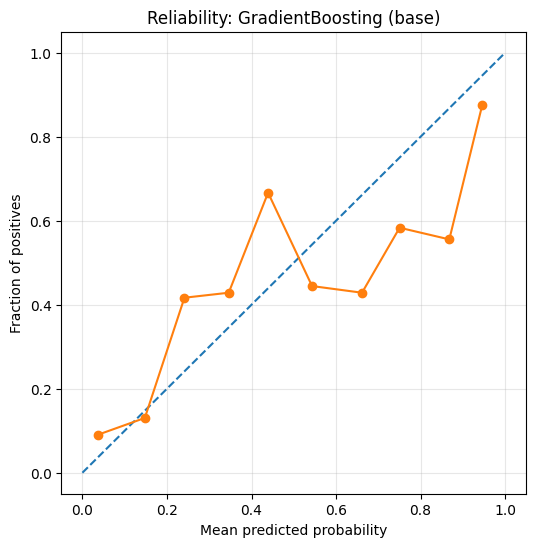

Tip: For calibrated curves, compare base vs Platt/Isotonic results in Experiment 1.


In [6]:
# Reliability diagrams for the diabetes experiment
# This cell is self-contained so it can be run after a kernel restart.

# --- Safety setup: allow running this cell after Restart Kernel / running cells out of order ---
if "__CH6_L10_SETUP__" not in globals():
    # If you run a single experiment cell directly, we re-define the minimal setup here.
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path
    from typing import Tuple

    from sklearn.model_selection import train_test_split, StratifiedKFold
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
    from sklearn.calibration import calibration_curve, CalibratedClassifierCV
    from sklearn.isotonic import IsotonicRegression
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier

    DATASETS = {
        "diabetes": Path("../../../Datasets/Classification/diabetes.csv"),
        "iris": Path("../../../Datasets/Classification/iris.csv"),
        "wine_quality": Path("../../../Datasets/Classification/Wine_Quality.csv"),
    }

    def load_diabetes() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["diabetes"])
        y = (df["classification"].astype(str).str.lower() == "diabetic").astype(int).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_iris() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["iris"])
        y = df["classification"].astype(str).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_wine_quality_binary(threshold: int = 7) -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["wine_quality"])
        y = (df["quality"] >= threshold).astype(int).to_numpy()
        X = df.drop(columns=["quality"])
        return X, y

    def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
        num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
        cat_cols = [c for c in X.columns if c not in num_cols]
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
        cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
        return ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])

    def expected_calibration_error(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10) -> float:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        bins = np.linspace(0.0, 1.0, n_bins + 1)
        ece = 0.0
        for i in range(n_bins):
            lo, hi = bins[i], bins[i + 1]
            mask = (p_pred >= lo) & (p_pred < hi) if i < n_bins - 1 else (p_pred >= lo) & (p_pred <= hi)
            if not np.any(mask):
                continue
            acc = y_true[mask].mean()
            conf = p_pred[mask].mean()
            ece += mask.mean() * abs(acc - conf)
        return float(ece)

    def evaluate_binary(y_true: np.ndarray, p_pred: np.ndarray) -> dict:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        eps = 1e-15
        p_clip = np.clip(p_pred, eps, 1 - eps)
        y_hat = (p_pred >= 0.5).astype(int)
        return {
            "brier": float(brier_score_loss(y_true, p_clip)),
            "log_loss": float(log_loss(y_true, np.c_[1 - p_clip, p_clip])),
            "roc_auc": float(roc_auc_score(y_true, p_clip)),
            "accuracy@0.5": float(accuracy_score(y_true, y_hat)),
            "ece": float(expected_calibration_error(y_true, p_clip, n_bins=10)),
        }

    def plot_reliability(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10, title: str = "Reliability diagram"):
        frac_pos, mean_pred = calibration_curve(np.asarray(y_true), np.asarray(p_pred), n_bins=n_bins, strategy="uniform")
        plt.figure(figsize=(6, 6))
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.plot(mean_pred, frac_pos, marker="o")
        plt.xlabel("Mean predicted probability")
        plt.ylabel("Fraction of positives")
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.show()

    def print_metrics_table(results: dict, sort_by: str = "brier", ascending: bool = True):
        rows = []
        for name, metrics in results.items():
            row = {"model": name}
            if isinstance(metrics, dict):
                row.update(metrics)
            rows.append(row)
        df = pd.DataFrame(rows)
        if sort_by in df.columns:
            df = df.sort_values(by=sort_by, ascending=ascending)
        try:
            from IPython.display import display
            display(df)
        except Exception:
            print(df.to_string(index=False))

    __CH6_L10_SETUP__ = True

# Reload + split
X, y = load_diabetes()
pre = make_preprocessor(X)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_calib, X_test, y_calib, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

base_models = {
    "RandomForest": RandomForestClassifier(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

def fit_base_pipeline(model):
    return Pipeline(steps=[("pre", pre), ("model", model)])

for model_name, model in base_models.items():
    pipe = fit_base_pipeline(model)
    pipe.fit(X_train, y_train)

    p_test = pipe.predict_proba(X_test)[:, 1]
    plot_reliability(y_test, p_test, title=f"Reliability: {model_name} (base)")

print("Tip: For calibrated curves, compare base vs Platt/Isotonic results in Experiment 1.")


,model,brier,log_loss,roc_auc,accuracy@0.5,ece
0,RF (base),0.165069,0.491937,0.814328,0.750000,0.036056
2,RF + isotonic (CV),0.165648,0.498879,0.815881,0.760417,0.056262
1,RF + sigmoid (CV),0.166257,0.499075,0.815403,0.760417,0.057031


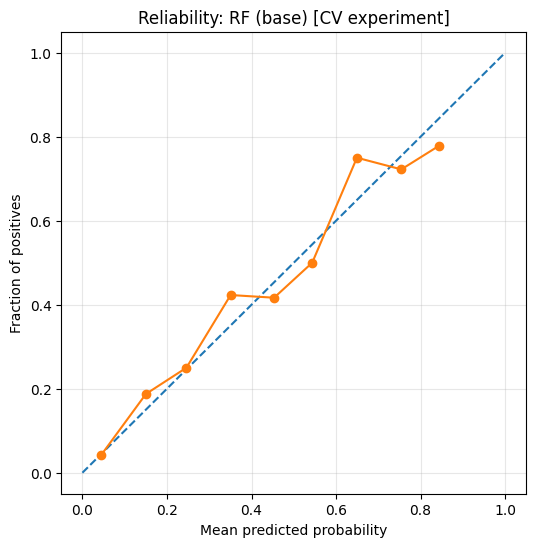

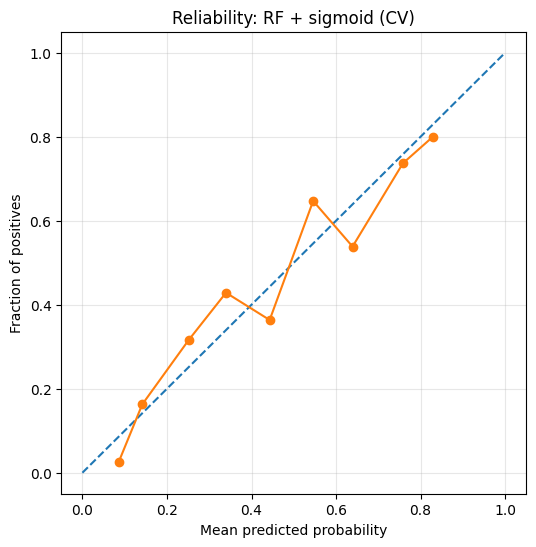

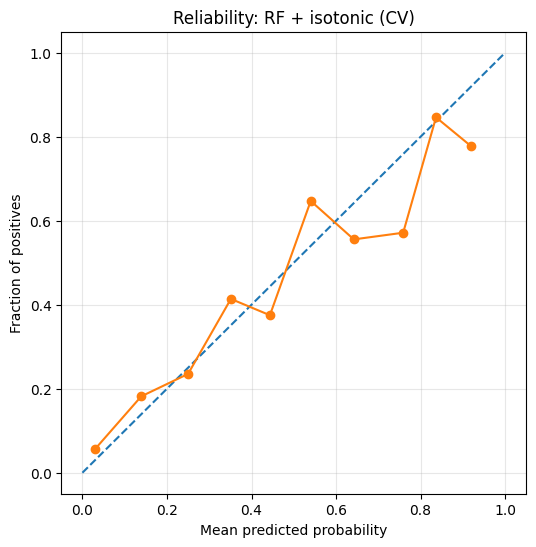

In [7]:
# --- Safety setup: allow running this cell after Restart Kernel / running cells out of order ---
if "__CH6_L10_SETUP__" not in globals():
    # If you run a single experiment cell directly, we re-define the minimal setup here.
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path
    from typing import Tuple

    from sklearn.model_selection import train_test_split, StratifiedKFold
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
    from sklearn.calibration import calibration_curve, CalibratedClassifierCV
    from sklearn.isotonic import IsotonicRegression
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier

    DATASETS = {
        "diabetes": Path("../../../Datasets/Classification/diabetes.csv"),
        "iris": Path("../../../Datasets/Classification/iris.csv"),
        "wine_quality": Path("../../../Datasets/Classification/Wine_Quality.csv"),
    }

    def load_diabetes() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["diabetes"])
        y = (df["classification"].astype(str).str.lower() == "diabetic").astype(int).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_iris() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["iris"])
        y = df["classification"].astype(str).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_wine_quality_binary(threshold: int = 7) -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["wine_quality"])
        y = (df["quality"] >= threshold).astype(int).to_numpy()
        X = df.drop(columns=["quality"])
        return X, y

    def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
        num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
        cat_cols = [c for c in X.columns if c not in num_cols]
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
        cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
        return ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])

    def expected_calibration_error(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10) -> float:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        bins = np.linspace(0.0, 1.0, n_bins + 1)
        ece = 0.0
        for i in range(n_bins):
            lo, hi = bins[i], bins[i + 1]
            mask = (p_pred >= lo) & (p_pred < hi) if i < n_bins - 1 else (p_pred >= lo) & (p_pred <= hi)
            if not np.any(mask):
                continue
            acc = y_true[mask].mean()
            conf = p_pred[mask].mean()
            ece += mask.mean() * abs(acc - conf)
        return float(ece)

    def evaluate_binary(y_true: np.ndarray, p_pred: np.ndarray) -> dict:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        eps = 1e-15
        p_clip = np.clip(p_pred, eps, 1 - eps)
        y_hat = (p_pred >= 0.5).astype(int)
        return {
            "brier": float(brier_score_loss(y_true, p_clip)),
            "log_loss": float(log_loss(y_true, np.c_[1 - p_clip, p_clip])),
            "roc_auc": float(roc_auc_score(y_true, p_clip)),
            "accuracy@0.5": float(accuracy_score(y_true, y_hat)),
            "ece": float(expected_calibration_error(y_true, p_clip, n_bins=10)),
        }

    def plot_reliability(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10, title: str = "Reliability diagram"):
        frac_pos, mean_pred = calibration_curve(np.asarray(y_true), np.asarray(p_pred), n_bins=n_bins, strategy="uniform")
        plt.figure(figsize=(6, 6))
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.plot(mean_pred, frac_pos, marker="o")
        plt.xlabel("Mean predicted probability")
        plt.ylabel("Fraction of positives")
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.show()

    def print_metrics_table(results: dict, sort_by: str = "brier", ascending: bool = True):
        rows = []
        for name, metrics in results.items():
            row = {"model": name}
            if isinstance(metrics, dict):
                row.update(metrics)
            rows.append(row)
        df = pd.DataFrame(rows)
        if sort_by in df.columns:
            df = df.sort_values(by=sort_by, ascending=ascending)
        try:
            from IPython.display import display
            display(df)
        except Exception:
            print(df.to_string(index=False))

    __CH6_L10_SETUP__ = True

# ------------------------------------------------------------------------------------
# Experiment 2: Cross-validated calibration with CalibratedClassifierCV
# ------------------------------------------------------------------------------------
# This protocol is usually preferred because it uses out-of-fold predictions for calibration,
# reducing the chance of leakage while using more data effectively.

X, y = load_diabetes()
pre = make_preprocessor(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# Base estimator (inside the pipeline)
rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

pipe_rf = Pipeline(steps=[("pre", pre), ("model", rf)])

# Calibrated models:
# - method='sigmoid' ~ Platt scaling (fits a logistic regression on scores)
# - method='isotonic' ~ isotonic regression
cal_sigmoid = CalibratedClassifierCV(pipe_rf, method="sigmoid", cv=5)
cal_isotonic = CalibratedClassifierCV(pipe_rf, method="isotonic", cv=5)

# Fit
pipe_rf.fit(X_train, y_train)
cal_sigmoid.fit(X_train, y_train)
cal_isotonic.fit(X_train, y_train)

# Predict
p_base = pipe_rf.predict_proba(X_test)[:, 1]
p_sig = cal_sigmoid.predict_proba(X_test)[:, 1]
p_iso = cal_isotonic.predict_proba(X_test)[:, 1]

results = {
    "RF (base)": evaluate_binary(y_test, p_base),
    "RF + sigmoid (CV)": evaluate_binary(y_test, p_sig),
    "RF + isotonic (CV)": evaluate_binary(y_test, p_iso),
}
print_metrics_table(results)

plot_reliability(y_test, p_base, title="Reliability: RF (base) [CV experiment]")
plot_reliability(y_test, p_sig, title="Reliability: RF + sigmoid (CV)")
plot_reliability(y_test, p_iso, title="Reliability: RF + isotonic (CV)")


## ۷) کالیبراسیون چندکلاسه (نمای کلی کوتاه)

برای $C>2$ کلاس، کالیبراسیون یعنی بردار احتمال $\\hat{\\mathbf{p}}(x)\\in\\Delta^{C-1}$ معنا داشته باشد:
اگر مدل برای کلاس $c$ احتمال ۰٫۸ بدهد، آن رخداد باید تقریباً ۸۰٪ مواقع رخ دهد (با شرط‌بندی مناسب).

روش‌های عملی:
- **کالیبراسیون One-vs-Rest:** کالیبره‌کردن احتمال هر کلاس به‌صورت جداگانه (خیلی رایج).
- **Isotonic چندکلاسه (پیچیده):** به‌خاطر قیدهای simplex کمتر رایج است.
- **Temperature scaling:** در deep learning رایج است؛ برای ML کلاسیک معمولاً از `CalibratedClassifierCV` استفاده می‌شود.

در این نوت‌بوک، کالیبراسیون چندکلاسه را روی دیتاست Iris نشان می‌دهیم.


Multiclass log loss:
  ExtraTrees (base):     0.1449
  ExtraTrees + sigmoid:  0.2648
  ExtraTrees + isotonic: 0.1448

Mean one-vs-rest ECE (10 bins):
  ExtraTrees (base):     0.0577
  ExtraTrees + sigmoid:  0.1244
  ExtraTrees + isotonic: 0.0612


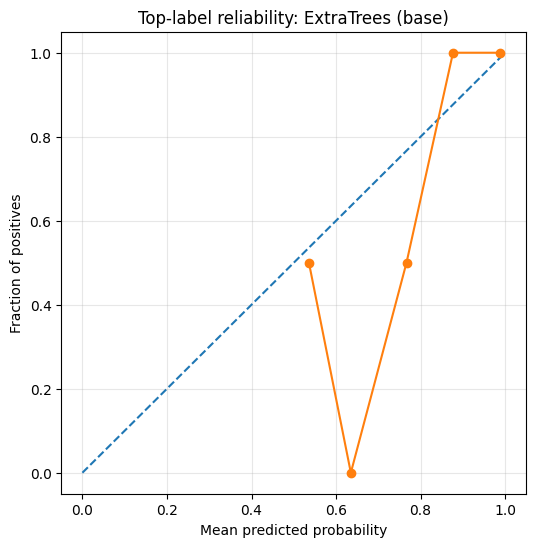

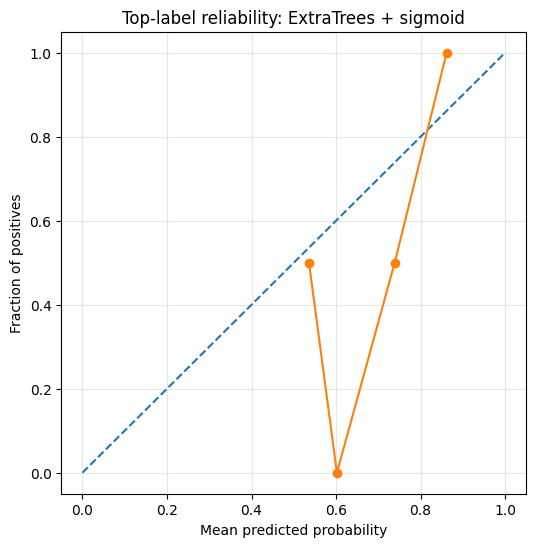

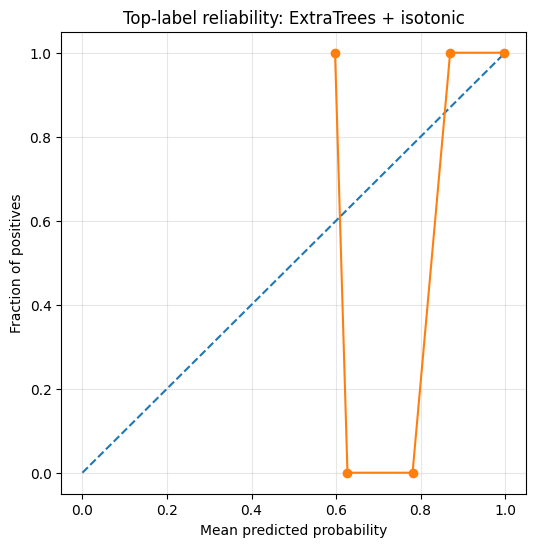

In [8]:
# --- Safety setup: allow running this cell after Restart Kernel / running cells out of order ---
if "__CH6_L10_SETUP__" not in globals():
    # If you run a single experiment cell directly, we re-define the minimal setup here.
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path
    from typing import Tuple

    from sklearn.model_selection import train_test_split, StratifiedKFold
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
    from sklearn.calibration import calibration_curve, CalibratedClassifierCV
    from sklearn.isotonic import IsotonicRegression
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier

    DATASETS = {
        "diabetes": Path("../../../Datasets/Classification/diabetes.csv"),
        "iris": Path("../../../Datasets/Classification/iris.csv"),
        "wine_quality": Path("../../../Datasets/Classification/Wine_Quality.csv"),
    }

    def load_diabetes() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["diabetes"])
        y = (df["classification"].astype(str).str.lower() == "diabetic").astype(int).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_iris() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["iris"])
        y = df["classification"].astype(str).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_wine_quality_binary(threshold: int = 7) -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["wine_quality"])
        y = (df["quality"] >= threshold).astype(int).to_numpy()
        X = df.drop(columns=["quality"])
        return X, y

    def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
        num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
        cat_cols = [c for c in X.columns if c not in num_cols]
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
        cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
        return ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])

    def expected_calibration_error(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10) -> float:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        bins = np.linspace(0.0, 1.0, n_bins + 1)
        ece = 0.0
        for i in range(n_bins):
            lo, hi = bins[i], bins[i + 1]
            mask = (p_pred >= lo) & (p_pred < hi) if i < n_bins - 1 else (p_pred >= lo) & (p_pred <= hi)
            if not np.any(mask):
                continue
            acc = y_true[mask].mean()
            conf = p_pred[mask].mean()
            ece += mask.mean() * abs(acc - conf)
        return float(ece)

    def evaluate_binary(y_true: np.ndarray, p_pred: np.ndarray) -> dict:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        eps = 1e-15
        p_clip = np.clip(p_pred, eps, 1 - eps)
        y_hat = (p_pred >= 0.5).astype(int)
        return {
            "brier": float(brier_score_loss(y_true, p_clip)),
            "log_loss": float(log_loss(y_true, np.c_[1 - p_clip, p_clip])),
            "roc_auc": float(roc_auc_score(y_true, p_clip)),
            "accuracy@0.5": float(accuracy_score(y_true, y_hat)),
            "ece": float(expected_calibration_error(y_true, p_clip, n_bins=10)),
        }

    def plot_reliability(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10, title: str = "Reliability diagram"):
        frac_pos, mean_pred = calibration_curve(np.asarray(y_true), np.asarray(p_pred), n_bins=n_bins, strategy="uniform")
        plt.figure(figsize=(6, 6))
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.plot(mean_pred, frac_pos, marker="o")
        plt.xlabel("Mean predicted probability")
        plt.ylabel("Fraction of positives")
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.show()

    def print_metrics_table(results: dict, sort_by: str = "brier", ascending: bool = True):
        rows = []
        for name, metrics in results.items():
            row = {"model": name}
            if isinstance(metrics, dict):
                row.update(metrics)
            rows.append(row)
        df = pd.DataFrame(rows)
        if sort_by in df.columns:
            df = df.sort_values(by=sort_by, ascending=ascending)
        try:
            from IPython.display import display
            display(df)
        except Exception:
            print(df.to_string(index=False))

    __CH6_L10_SETUP__ = True

# ------------------------------------------------------------------------------------
# Experiment 3: Multiclass calibration on iris.csv
# ------------------------------------------------------------------------------------
X, y = load_iris()
pre = make_preprocessor(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# A multiclass ensemble model
et = ExtraTreesClassifier(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=1
)
pipe_et = Pipeline(steps=[("pre", pre), ("model", et)])

# Cross-validated calibration for multiclass (one-vs-rest internally in sklearn)
cal_et_sigmoid = CalibratedClassifierCV(pipe_et, method="sigmoid", cv=5)
cal_et_isotonic = CalibratedClassifierCV(pipe_et, method="isotonic", cv=5)

pipe_et.fit(X_train, y_train)
cal_et_sigmoid.fit(X_train, y_train)
cal_et_isotonic.fit(X_train, y_train)

proba_base = pipe_et.predict_proba(X_test)
proba_sig = cal_et_sigmoid.predict_proba(X_test)
proba_iso = cal_et_isotonic.predict_proba(X_test)

# Multiclass log loss is a standard proper scoring rule
loss_base = log_loss(y_test, proba_base)
loss_sig = log_loss(y_test, proba_sig)
loss_iso = log_loss(y_test, proba_iso)

print("Multiclass log loss:")
print(f"  ExtraTrees (base):     {loss_base:.4f}")
print(f"  ExtraTrees + sigmoid:  {loss_sig:.4f}")
print(f"  ExtraTrees + isotonic: {loss_iso:.4f}")

# A simple multiclass calibration proxy:
# Compute ECE for each class in a one-vs-rest way, then average.
classes = pipe_et.named_steps["model"].classes_

def multiclass_ece(y_true, proba, n_bins=10):
    eces = []
    for c in classes:
        y_bin = (y_true == c).astype(int)
        p_c = proba[:, np.where(classes == c)[0][0]]
        eces.append(expected_calibration_error(y_bin, p_c, n_bins=n_bins))
    return float(np.mean(eces))

print("\nMean one-vs-rest ECE (10 bins):")
print(f"  ExtraTrees (base):     {multiclass_ece(y_test, proba_base):.4f}")
print(f"  ExtraTrees + sigmoid:  {multiclass_ece(y_test, proba_sig):.4f}")
print(f"  ExtraTrees + isotonic: {multiclass_ece(y_test, proba_iso):.4f}")

# Reliability plot for "predicted class confidence"
# (This answers: when the model says its top class has probability p, how often is it correct?)
def top_label_reliability(y_true, proba, title, n_bins=10):
    top_p = proba.max(axis=1)
    top_pred = classes[proba.argmax(axis=1)]
    top_correct = (top_pred == y_true).astype(int)
    plot_reliability(top_correct, top_p, title=title, n_bins=n_bins)

top_label_reliability(y_test, proba_base, title="Top-label reliability: ExtraTrees (base)")
top_label_reliability(y_test, proba_sig, title="Top-label reliability: ExtraTrees + sigmoid")
top_label_reliability(y_test, proba_iso, title="Top-label reliability: ExtraTrees + isotonic")


Base metrics (GradientBoosting):


,brier,log_loss,roc_auc,accuracy@0.5,ece
0,0.114597,0.357446,0.871399,0.837551,0.025096


,model,brier,log_loss,roc_auc,accuracy@0.5,ece
1,GB + Platt (small calib),0.115764,0.361794,0.864583,0.837551,0.021062
0,GB (base),0.116022,0.362888,0.864583,0.842449,0.025629
2,GB + Isotonic (small calib),0.116159,0.435266,0.864253,0.839184,0.018682


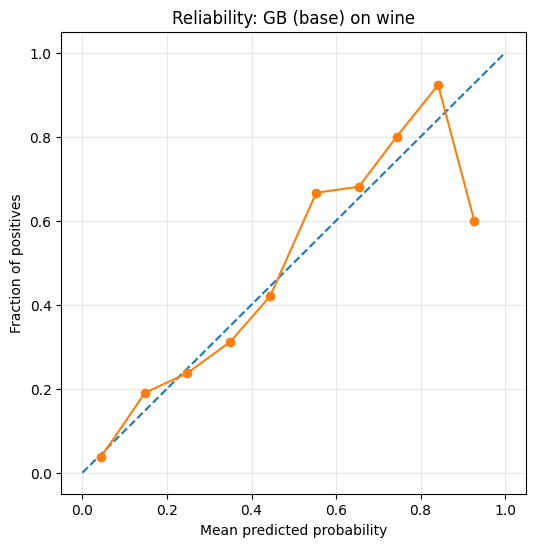

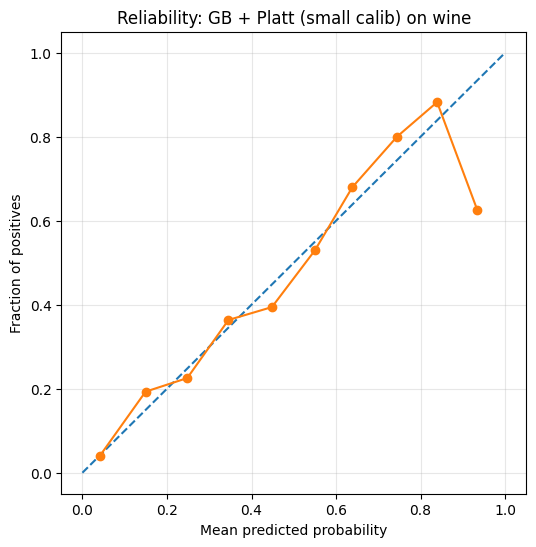

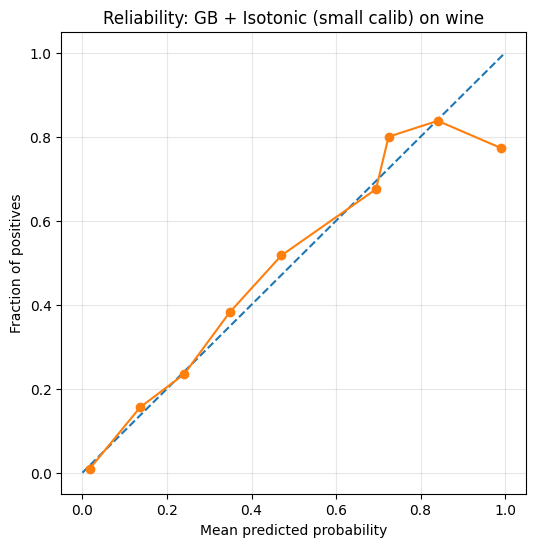

In [9]:
# --- Safety setup: allow running this cell after Restart Kernel / running cells out of order ---
if "__CH6_L10_SETUP__" not in globals():
    # If you run a single experiment cell directly, we re-define the minimal setup here.
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path
    from typing import Tuple

    from sklearn.model_selection import train_test_split, StratifiedKFold
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
    from sklearn.calibration import calibration_curve, CalibratedClassifierCV
    from sklearn.isotonic import IsotonicRegression
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier

    DATASETS = {
        "diabetes": Path("../../../Datasets/Classification/diabetes.csv"),
        "iris": Path("../../../Datasets/Classification/iris.csv"),
        "wine_quality": Path("../../../Datasets/Classification/Wine_Quality.csv"),
    }

    def load_diabetes() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["diabetes"])
        y = (df["classification"].astype(str).str.lower() == "diabetic").astype(int).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_iris() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["iris"])
        y = df["classification"].astype(str).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_wine_quality_binary(threshold: int = 7) -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["wine_quality"])
        y = (df["quality"] >= threshold).astype(int).to_numpy()
        X = df.drop(columns=["quality"])
        return X, y

    def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
        num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
        cat_cols = [c for c in X.columns if c not in num_cols]
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
        cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
        return ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])

    def expected_calibration_error(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10) -> float:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        bins = np.linspace(0.0, 1.0, n_bins + 1)
        ece = 0.0
        for i in range(n_bins):
            lo, hi = bins[i], bins[i + 1]
            mask = (p_pred >= lo) & (p_pred < hi) if i < n_bins - 1 else (p_pred >= lo) & (p_pred <= hi)
            if not np.any(mask):
                continue
            acc = y_true[mask].mean()
            conf = p_pred[mask].mean()
            ece += mask.mean() * abs(acc - conf)
        return float(ece)

    def evaluate_binary(y_true: np.ndarray, p_pred: np.ndarray) -> dict:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        eps = 1e-15
        p_clip = np.clip(p_pred, eps, 1 - eps)
        y_hat = (p_pred >= 0.5).astype(int)
        return {
            "brier": float(brier_score_loss(y_true, p_clip)),
            "log_loss": float(log_loss(y_true, np.c_[1 - p_clip, p_clip])),
            "roc_auc": float(roc_auc_score(y_true, p_clip)),
            "accuracy@0.5": float(accuracy_score(y_true, y_hat)),
            "ece": float(expected_calibration_error(y_true, p_clip, n_bins=10)),
        }

    def plot_reliability(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10, title: str = "Reliability diagram"):
        frac_pos, mean_pred = calibration_curve(np.asarray(y_true), np.asarray(p_pred), n_bins=n_bins, strategy="uniform")
        plt.figure(figsize=(6, 6))
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.plot(mean_pred, frac_pos, marker="o")
        plt.xlabel("Mean predicted probability")
        plt.ylabel("Fraction of positives")
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.show()

    def print_metrics_table(results: dict, sort_by: str = "brier", ascending: bool = True):
        rows = []
        for name, metrics in results.items():
            row = {"model": name}
            if isinstance(metrics, dict):
                row.update(metrics)
            rows.append(row)
        df = pd.DataFrame(rows)
        if sort_by in df.columns:
            df = df.sort_values(by=sort_by, ascending=ascending)
        try:
            from IPython.display import display
            display(df)
        except Exception:
            print(df.to_string(index=False))

    __CH6_L10_SETUP__ = True

# ------------------------------------------------------------------------------------
# Experiment 4: Wine quality (binary) and the overfitting story of isotonic regression
# ------------------------------------------------------------------------------------
X, y = load_wine_quality_binary(threshold=7)  # good (>=7) vs not-good
pre = make_preprocessor(X)

# Make a standard split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

gb = GradientBoostingClassifier(random_state=42)
pipe_gb = Pipeline(steps=[("pre", pre), ("model", gb)])
pipe_gb.fit(X_train, y_train)

p_base = pipe_gb.predict_proba(X_test)[:, 1]
print("Base metrics (GradientBoosting):")
display(pd.DataFrame([evaluate_binary(y_test, p_base)]))

# Now create a *small* calibration set to illustrate isotonic variance
X_train2, X_calib, y_train2, y_calib = train_test_split(X_train, y_train, test_size=0.15, stratify=y_train, random_state=42)

pipe_gb2 = Pipeline(steps=[("pre", pre), ("model", gb)])
pipe_gb2.fit(X_train2, y_train2)

p_calib = pipe_gb2.predict_proba(X_calib)[:, 1]
p_test = pipe_gb2.predict_proba(X_test)[:, 1]

# Platt (sigmoid) on logit(prob)
eps = 1e-6
z_calib = np.log(np.clip(p_calib, eps, 1-eps) / np.clip(1-p_calib, eps, 1-eps)).reshape(-1, 1)
platt = LogisticRegression(solver="lbfgs")
platt.fit(z_calib, y_calib)
z_test = np.log(np.clip(p_test, eps, 1-eps) / np.clip(1-p_test, eps, 1-eps)).reshape(-1, 1)
p_platt = platt.predict_proba(z_test)[:, 1]

# Isotonic
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(p_calib, y_calib)
p_iso = iso.transform(p_test)

res = {
    "GB (base)": evaluate_binary(y_test, p_test),
    "GB + Platt (small calib)": evaluate_binary(y_test, p_platt),
    "GB + Isotonic (small calib)": evaluate_binary(y_test, p_iso),
}
print_metrics_table(res)

plot_reliability(y_test, p_test, title="Reliability: GB (base) on wine")
plot_reliability(y_test, p_platt, title="Reliability: GB + Platt (small calib) on wine")
plot_reliability(y_test, p_iso, title="Reliability: GB + Isotonic (small calib) on wine")


## ۴٫۵) (اختیاری) حل isotonic regression: الگوریتم PAV

Isotonic regression با خطای مربعی یک ویژگی زیبا دارد:  
راه‌حل بهینه یک تابع پله‌ای است و می‌توان آن را دقیقاً با **Pool-Adjacent-Violators (PAV)** محاسبه کرد.

در ادامه PAV را از صفر پیاده‌سازی می‌کنیم و با پیاده‌سازی scikit-learn مقایسه می‌کنیم.


,s_sorted,y_sorted,f_pav,f_sklearn
0,0.10,0,0.000000,0.000000
1,0.20,1,0.666667,0.666667
2,0.30,1,0.666667,0.666667
3,0.35,0,0.666667,0.666667
4,0.40,1,1.000000,1.000000
5,0.80,1,1.000000,1.000000


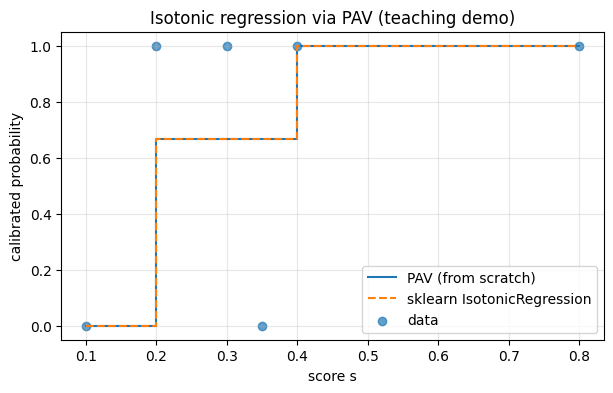

In [10]:
# --- Safety setup: allow running this cell after Restart Kernel / running cells out of order ---
if "__CH6_L10_SETUP__" not in globals():
    # If you run a single experiment cell directly, we re-define the minimal setup here.
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path
    from typing import Tuple

    from sklearn.model_selection import train_test_split, StratifiedKFold
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
    from sklearn.calibration import calibration_curve, CalibratedClassifierCV
    from sklearn.isotonic import IsotonicRegression
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier

    DATASETS = {
        "diabetes": Path("../../../Datasets/Classification/diabetes.csv"),
        "iris": Path("../../../Datasets/Classification/iris.csv"),
        "wine_quality": Path("../../../Datasets/Classification/Wine_Quality.csv"),
    }

    def load_diabetes() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["diabetes"])
        y = (df["classification"].astype(str).str.lower() == "diabetic").astype(int).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_iris() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["iris"])
        y = df["classification"].astype(str).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_wine_quality_binary(threshold: int = 7) -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["wine_quality"])
        y = (df["quality"] >= threshold).astype(int).to_numpy()
        X = df.drop(columns=["quality"])
        return X, y

    def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
        num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
        cat_cols = [c for c in X.columns if c not in num_cols]
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
        cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
        return ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])

    def expected_calibration_error(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10) -> float:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        bins = np.linspace(0.0, 1.0, n_bins + 1)
        ece = 0.0
        for i in range(n_bins):
            lo, hi = bins[i], bins[i + 1]
            mask = (p_pred >= lo) & (p_pred < hi) if i < n_bins - 1 else (p_pred >= lo) & (p_pred <= hi)
            if not np.any(mask):
                continue
            acc = y_true[mask].mean()
            conf = p_pred[mask].mean()
            ece += mask.mean() * abs(acc - conf)
        return float(ece)

    def evaluate_binary(y_true: np.ndarray, p_pred: np.ndarray) -> dict:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        eps = 1e-15
        p_clip = np.clip(p_pred, eps, 1 - eps)
        y_hat = (p_pred >= 0.5).astype(int)
        return {
            "brier": float(brier_score_loss(y_true, p_clip)),
            "log_loss": float(log_loss(y_true, np.c_[1 - p_clip, p_clip])),
            "roc_auc": float(roc_auc_score(y_true, p_clip)),
            "accuracy@0.5": float(accuracy_score(y_true, y_hat)),
            "ece": float(expected_calibration_error(y_true, p_clip, n_bins=10)),
        }

    def plot_reliability(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10, title: str = "Reliability diagram"):
        frac_pos, mean_pred = calibration_curve(np.asarray(y_true), np.asarray(p_pred), n_bins=n_bins, strategy="uniform")
        plt.figure(figsize=(6, 6))
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.plot(mean_pred, frac_pos, marker="o")
        plt.xlabel("Mean predicted probability")
        plt.ylabel("Fraction of positives")
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.show()

    def print_metrics_table(results: dict, sort_by: str = "brier", ascending: bool = True):
        rows = []
        for name, metrics in results.items():
            row = {"model": name}
            if isinstance(metrics, dict):
                row.update(metrics)
            rows.append(row)
        df = pd.DataFrame(rows)
        if sort_by in df.columns:
            df = df.sort_values(by=sort_by, ascending=ascending)
        try:
            from IPython.display import display
            display(df)
        except Exception:
            print(df.to_string(index=False))

    __CH6_L10_SETUP__ = True

# ------------------------------------------------------------------------------------
# (Optional) From scratch: Pool-Adjacent-Violators (PAV) for isotonic regression
# ------------------------------------------------------------------------------------
# Isotonic regression solves:
#   minimize sum_i (y_i - f(s_i))^2   subject to f is non-decreasing in s
#
# The PAV algorithm produces the exact L2 isotonic regression solution in O(n) time
# once the data is sorted by s. The solution is piecewise constant: it forms "blocks"
# where adjacent violations of monotonicity are pooled/merged.

def pav_isotonic(s: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Return (s_sorted, f_values) where f_values is isotonic fit at each s_sorted.
    This is a simple implementation for teaching purposes.
    """
    s = np.asarray(s, dtype=float)
    y = np.asarray(y, dtype=float)
    order = np.argsort(s)
    s_sorted = s[order]
    y_sorted = y[order]

    # Each block has (weight, value). For standard L2 isotonic, weights can be 1 per sample.
    weights = []
    values = []

    for yi in y_sorted:
        weights.append(1.0)
        values.append(float(yi))

        # Merge while monotonicity is violated: previous value > current value
        while len(values) >= 2 and values[-2] > values[-1]:
            w1, w2 = weights[-2], weights[-1]
            v1, v2 = values[-2], values[-1]
            w = w1 + w2
            v = (w1 * v1 + w2 * v2) / w
            # Replace last two blocks with merged block
            weights[-2:] = [w]
            values[-2:] = [v]

    # Expand block values back to sample-level values
    f = np.empty_like(y_sorted)
    idx = 0
    for w, v in zip(weights, values):
        w_int = int(round(w))
        f[idx:idx + w_int] = v
        idx += w_int

    return s_sorted, f

# Demo on a small synthetic example
s_demo = np.array([0.1, 0.2, 0.3, 0.35, 0.4, 0.8])
y_demo = np.array([0, 1, 1, 0, 1, 1])  # intentionally creates violations
s_sorted, f_pav = pav_isotonic(s_demo, y_demo)

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(s_demo, y_demo)
f_sklearn = iso.transform(s_sorted)

df_demo = pd.DataFrame({
    "s_sorted": s_sorted,
    "y_sorted": y_demo[np.argsort(s_demo)],
    "f_pav": f_pav,
    "f_sklearn": f_sklearn
})
display(df_demo)

plt.figure(figsize=(7, 4))
plt.step(s_sorted, f_pav, where="post", label="PAV (from scratch)")
plt.step(s_sorted, f_sklearn, where="post", linestyle="--", label="sklearn IsotonicRegression")
plt.scatter(s_demo, y_demo, alpha=0.7, label="data")
plt.xlabel("score s")
plt.ylabel("calibrated probability")
plt.title("Isotonic regression via PAV (teaching demo)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## ۱۰) نکات ویژه‌ی Ensembleها و راهنمای عملی

### Random Forest / ExtraTrees
- درخت‌ها فضای ویژگی را به برگ‌ها تقسیم می‌کنند؛ هر برگ یک فراوانی کلاس پیش‌بینی می‌کند.
- با تعداد زیاد درخت، احتمال‌ها اغلب «صاف‌تر» می‌شوند و گاهی **کم‌اطمینانی** ایجاد می‌کنند.
- اگر درخت‌ها خیلی عمیق با برگ‌های بسیار کوچک باشند، احتمال‌ها پرنوسان می‌شوند؛ کالیبراسیون می‌تواند کمک کند.

**قاعده‌ی تجربی:** RF/ExtraTrees با داده‌ی کافی اغلب از **isotonic** سود می‌برند، اما وقتی داده کم است sigmoid امن‌تر است.

### Gradient Boosting / AdaBoost
- Boosting marginها را بزرگ می‌کند؛ احتمال‌های پیش‌بینی‌شده می‌توانند **بیش‌اطمینان** شوند.
- early stopping و learning rate روی کالیبراسیون اثر زیادی دارند.

**قاعده‌ی تجربی:** Boosting اغلب از **sigmoid** (Platt scaling) سود می‌برد، مخصوصاً وقتی بدکالیبراسیون نزدیک به S-شکل باشد.

### Stacking / Voting
- میانگین‌گرفتن احتمال‌ها الزاماً کالیبراسیون را حفظ نمی‌کند.
- یک meta-learner که با log loss آموزش دیده ممکن است احتمال‌های خوبی بدهد، اما هنوز می‌تواند بدکالیبره شود اگر leakage یا آثار نامتوازنی کلاس وجود داشته باشد.

**قاعده‌ی تجربی:** حتی اگر stacker شما logistic regression است، کالیبراسیون را ارزیابی کنید؛ در صورت نیاز یک کالیبراتور نهایی اضافه کنید.

### دنبال یک عدد واحد نروید
معیارهای کالیبراسیون ممکن است در جهت‌های مختلف حرکت کنند:
- بهتر شدن log loss ممکن است کمی ECE را بدتر کند یا برعکس،
بسته به binning و اندازه‌ی نمونه. نمودارهای reliability را ببینید.


## ۱۱) خطاهای رایج (به چه چیزهایی دقت کنیم؟)

1. **کالیبره‌کردن روی داده‌ی آموزش**  
   باعث معیارهای کالیبراسیونِ بیش از حد خوش‌بینانه می‌شود (leakage).

2. **Isotonic با calibration set کوچک**  
   می‌تواند overfit کند: منحنی reliability روی calib عالی است اما روی test بدتر می‌شود.

3. **عدم‌توازن کلاس + سردرگمی آستانه**  
   کالیبراسیون به‌خودیِ خود imbalance را «درست» نمی‌کند. شما هنوز نیاز دارید:
   - معیارهای مناسب (مثل PR AUC)،
   - تنظیم آستانه،
   - و شاید class weight یا re-sampling.

4. **جابجایی توزیع (dataset shift)**  
   کالیبراسیون یک گزاره درباره‌ی توزیعی است که روی آن کالیبره کرده‌اید.
   تحت covariate shift یا label shift، کالیبراسیون می‌تواند خراب شود.
   (این موضوع مستقیم به فصل‌های بعدی درباره‌ی reliability و conformal prediction وصل است.)

5. **معیار زیاد، زمینه کم**  
   همیشه عددها را با حداقل یک نمودار و یک تفسیر کوتاهِ تصمیم‌محور همراه کنید.


## ۱۲) انتخاب بین Platt (sigmoid) و isotonic (راهنمای سریع)

از **sigmoid** استفاده کنید وقتی:
- calibration set کوچک/متوسط است،
- انتظار بدکالیبراسیونی نرم و S-شکل دارید،
- می‌خواهید اصلاح کم‌واریانس داشته باشید.

از **isotonic** استفاده کنید وقتی:
- داده‌ی کالیبراسیون زیاد دارید،
- منحنی کالیبراسیون واضحاً غیرسیگموید است،
- می‌توانید واریانس بیشتر را تحمل کنید.

اگر مطمئن نیستید:
- با **sigmoid** شروع کنید،
- سپس isotonic را امتحان کنید و روی یک *test set واقعی* مقایسه کنید،
- روشی را انتخاب کنید که **log loss** را بهتر کند و نمودار reliability را بدون نشانه‌های overfitting بهبود دهد.


## ۹) نگاه عمیق‌تر: امتیازها، نسبت درست‌نمایی، و نگاشت‌های یکنواخت کالیبراسیون

برای طبقه‌بندی دودویی با چگالی‌های شرطی $p(x\\mid y=1)$ و $p(x\\mid y=0)$، پسینِ بیزی برابر است با:

$$
\\mathbb{P}(y=1\\mid x) = \\frac{\\pi\\,p(x\\mid y=1)}{\\pi\\,p(x\\mid y=1) + (1-\\pi)\\,p(x\\mid y=0)},
$$

که در آن $\\pi=\\mathbb{P}(y=1)$ پیشین است.

نسبت درست‌نمایی را تعریف کنید:
$$
\\Lambda(x)=\\frac{p(x\\mid y=1)}{p(x\\mid y=0)}.
$$

در این صورت پسین یک **سیگموید** از log-likelihood ratio است:
$$
\\mathbb{P}(y=1\\mid x)=\\sigma\\big(\\log \\Lambda(x) + \\log\\tfrac{\\pi}{1-\\pi}\\big).
$$

این رابطه به تفسیر Platt scaling کمک می‌کند:
- اگر امتیاز مدل $s(x)$ تقریباً یک **تبدیل آفین** از $\\log\\Lambda(x)$ باشد،
  آنگاه sigmoid calibration از نظر نظری توجیه خوبی دارد.
- اگر $s(x)$ فقط یک تبدیل یکنواخت از $\\Lambda(x)$ باشد، یک نگاشت یکنواخت انعطاف‌پذیرتر (isotonic) می‌تواند کمک کند.

**نتیجه:** calibration جادو نیست—هدفش ترمیم نگاشت بین امتیازهای مدل و پسینِ واقعی است.


## ۱۳) مینی‌بنچمارک روی چند دیتاست (دودویی)

برای اینکه ببینیم رفتار کالیبراسیون به **مدل** و **دیتاست** وابسته است، یک benchmark کوچک اجرا می‌کنیم:
- دیتاست‌ها: diabetes، wine_quality (دودویی)
- مدل‌ها: RandomForest، GradientBoosting، ExtraTrees
- حالت‌ها: base، کالیبره با sigmoid، کالیبره با isotonic (CV)

در تفسیر نتایج، روی **log loss** و نمودار reliability تمرکز کنید.


In [11]:
# --- Safety setup: allow running this cell after Restart Kernel / running cells out of order ---
if "__CH6_L10_SETUP__" not in globals():
    # If you run a single experiment cell directly, we re-define the minimal setup here.
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path
    from typing import Tuple

    from sklearn.model_selection import train_test_split, StratifiedKFold
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
    from sklearn.calibration import calibration_curve, CalibratedClassifierCV
    from sklearn.isotonic import IsotonicRegression
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier

    DATASETS = {
        "diabetes": Path("../../../Datasets/Classification/diabetes.csv"),
        "iris": Path("../../../Datasets/Classification/iris.csv"),
        "wine_quality": Path("../../../Datasets/Classification/Wine_Quality.csv"),
    }

    def load_diabetes() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["diabetes"])
        y = (df["classification"].astype(str).str.lower() == "diabetic").astype(int).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_iris() -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["iris"])
        y = df["classification"].astype(str).to_numpy()
        X = df.drop(columns=["classification"])
        return X, y

    def load_wine_quality_binary(threshold: int = 7) -> Tuple[pd.DataFrame, np.ndarray]:
        df = pd.read_csv(DATASETS["wine_quality"])
        y = (df["quality"] >= threshold).astype(int).to_numpy()
        X = df.drop(columns=["quality"])
        return X, y

    def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
        num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
        cat_cols = [c for c in X.columns if c not in num_cols]
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
        cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
        return ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])

    def expected_calibration_error(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10) -> float:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        bins = np.linspace(0.0, 1.0, n_bins + 1)
        ece = 0.0
        for i in range(n_bins):
            lo, hi = bins[i], bins[i + 1]
            mask = (p_pred >= lo) & (p_pred < hi) if i < n_bins - 1 else (p_pred >= lo) & (p_pred <= hi)
            if not np.any(mask):
                continue
            acc = y_true[mask].mean()
            conf = p_pred[mask].mean()
            ece += mask.mean() * abs(acc - conf)
        return float(ece)

    def evaluate_binary(y_true: np.ndarray, p_pred: np.ndarray) -> dict:
        y_true = np.asarray(y_true)
        p_pred = np.asarray(p_pred)
        eps = 1e-15
        p_clip = np.clip(p_pred, eps, 1 - eps)
        y_hat = (p_pred >= 0.5).astype(int)
        return {
            "brier": float(brier_score_loss(y_true, p_clip)),
            "log_loss": float(log_loss(y_true, np.c_[1 - p_clip, p_clip])),
            "roc_auc": float(roc_auc_score(y_true, p_clip)),
            "accuracy@0.5": float(accuracy_score(y_true, y_hat)),
            "ece": float(expected_calibration_error(y_true, p_clip, n_bins=10)),
        }

    def plot_reliability(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10, title: str = "Reliability diagram"):
        frac_pos, mean_pred = calibration_curve(np.asarray(y_true), np.asarray(p_pred), n_bins=n_bins, strategy="uniform")
        plt.figure(figsize=(6, 6))
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.plot(mean_pred, frac_pos, marker="o")
        plt.xlabel("Mean predicted probability")
        plt.ylabel("Fraction of positives")
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.show()

    def print_metrics_table(results: dict, sort_by: str = "brier", ascending: bool = True):
        rows = []
        for name, metrics in results.items():
            row = {"model": name}
            if isinstance(metrics, dict):
                row.update(metrics)
            rows.append(row)
        df = pd.DataFrame(rows)
        if sort_by in df.columns:
            df = df.sort_values(by=sort_by, ascending=ascending)
        try:
            from IPython.display import display
            display(df)
        except Exception:
            print(df.to_string(index=False))

    __CH6_L10_SETUP__ = True

# ------------------------------------------------------------------------------------
# Experiment 5: A small benchmark across multiple datasets and ensembles
# ------------------------------------------------------------------------------------
# We will evaluate:
# - RandomForest and GradientBoosting on different datasets
# - base vs calibrated (sigmoid, isotonic) using CV calibration
#
# NOTE: This is meant for learning. For serious benchmarking, use nested CV and careful tuning.

def run_binary_benchmark(dataset_loader: Callable[[], Tuple[pd.DataFrame, np.ndarray]], dataset_name: str):
    X, y = dataset_loader()
    pre = make_preprocessor(X)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

    models = {
        "RandomForest": RandomForestClassifier(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1),
        "GradientBoosting": GradientBoostingClassifier(random_state=42),
        "ExtraTrees": ExtraTreesClassifier(n_estimators=500, min_samples_leaf=2, random_state=42, n_jobs=-1),
    }

    all_results = {}
    for name, model in models.items():
        base = Pipeline(steps=[("pre", pre), ("model", model)])
        base.fit(X_train, y_train)
        p_base = base.predict_proba(X_test)[:, 1]
        all_results[f"{name} (base)"] = evaluate_binary(y_test, p_base)

        cal_sig = CalibratedClassifierCV(base, method="sigmoid", cv=5)
        cal_iso = CalibratedClassifierCV(base, method="isotonic", cv=5)
        cal_sig.fit(X_train, y_train)
        cal_iso.fit(X_train, y_train)
        p_sig = cal_sig.predict_proba(X_test)[:, 1]
        p_iso = cal_iso.predict_proba(X_test)[:, 1]
        all_results[f"{name} + sigmoid"] = evaluate_binary(y_test, p_sig)
        all_results[f"{name} + isotonic"] = evaluate_binary(y_test, p_iso)

    df = pd.DataFrame(all_results).T
    df.insert(0, "dataset", dataset_name)
    return df

# Two binary tasks:
df1 = run_binary_benchmark(load_diabetes, "diabetes")
df2 = run_binary_benchmark(lambda: load_wine_quality_binary(threshold=7), "wine_quality_binary(th>=7)")

benchmark = pd.concat([df1, df2], axis=0)
display(benchmark.sort_values(by=["dataset", "log_loss"]))


,dataset,brier,log_loss,roc_auc,accuracy@0.5,ece
GradientBoosting + isotonic,diabetes,0.163664,0.486263,0.817433,0.750000,0.076496
GradientBoosting + sigmoid,diabetes,0.163732,0.491191,0.820418,0.739583,0.057317
RandomForest (base),diabetes,0.165372,0.493556,0.813254,0.744792,0.043725
RandomForest + sigmoid,diabetes,0.166235,0.499497,0.815284,0.755208,0.044552
ExtraTrees (base),diabetes,0.167361,0.501035,0.815164,0.729167,0.047118
ExtraTrees + sigmoid,diabetes,0.168415,0.502638,0.813731,0.739583,0.056811
RandomForest + isotonic,diabetes,0.167826,0.504158,0.810567,0.755208,0.058403
GradientBoosting (base),diabetes,0.173014,0.512805,0.825672,0.723958,0.112380
ExtraTrees + isotonic,diabetes,0.174076,0.519457,0.810388,0.739583,0.066587
ExtraTrees + isotonic,wine_quality_binary(th>=7),0.080369,0.269311,0.924974,0.899592,0.028617


## ۸) جمع‌بندی و تمرین‌ها

### جمع‌بندی
- Calibration می‌پرسد آیا $\\hat{p}$ از نظر احتمالاتی *معنادار* است یا نه، نه اینکه برچسب‌ها چقدر درست‌اند.
- Ensembleها ممکن است accuracy/AUC عالی داشته باشند ولی احتمال‌ها بدکالیبره باشند.
- **Platt scaling** یک سیگموید $\\sigma(As+B)$ برازش می‌کند؛ کم‌واریانس و مقاوم.
- **Isotonic regression** یک تابع یکنواخت یاد می‌گیرد؛ انعطاف‌پذیر ولی ممکن است overfit کند.
- از **پروتکل‌های درست** (داده‌ی جداگانه یا کالیبراسیون cross-validated) استفاده کنید تا leakage رخ ندهد.
- کالیبراسیون را با reliability diagram، ECE، Brier score و log loss بسنجید.

### تمرین‌ها (بعد از اجرای نوت‌بوک)
1. یک Ensemble دیگر (ExtraTrees، AdaBoost، HistGradientBoosting اگر موجود است) را امتحان کنید و رفتار کالیبراسیون را مقایسه کنید.
2. دیتاست را شدیداً نامتوازن کنید (مثلاً کلاس مثبت را downsample کنید) و ببینید کالیبراسیون چگونه تغییر می‌کند.
3. کالیبره‌کردن `predict_proba` را با کالیبره‌کردن `decision_function` (در صورت وجود) مقایسه کنید.
4. حساسیت به تعداد binها $K$ را در ECE و نمودارهای reliability بررسی کنید.
5. (اختیاری) **temperature scaling** را برای logitهای چندکلاسه پیاده‌سازی کنید و با sigmoid calibration مقایسه کنید.
